# Деревья принятия решений (Decision Tree)

## Обучение и визуализация дерева принятия решений

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, 2:] # Длина и ширина лепестка
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2)
tree_clf.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

Визуализируем обученное дерево принятия решений.

In [2]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file='iris_tree.dot',
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

In [3]:
from sklearn.tree import export_graphviz
from graphviz import Source

dot_data = export_graphviz(
    tree_clf,
    out_file=None,                    # не создаём .dot-файл
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

graph = Source(dot_data)
graph.render("iris_tree", format="png", cleanup=True)   # создаёт iris_tree.png

'iris_tree.png'

![Дерево решений](iris_tree.png)

## Вырабатывание прогнозов
Корневой узел - имеет дочерние узлы, Листовой узел - не имеет дочерних узлов.

Одним из многих качеств деревьев принятия решений является то, что они требуют совсем небольшой подготовки данных. В частности, для них вообще не нужно масштабирование или центрирование признаков.

Атрибут ___samples___ узла подсчитывает, к скольким обучающим образцам он применяется. Например, 100 обучающих образцов имеют длину лепетска больше 2.45 (глубина 1, справа), среди которых 54 образца имеют ширину лепестка меньше 1.75 (глубина 2, слева). Атрибут ___value___ узла сообщает, к скольким обучающим образцам каждого класса применяется этот узел: например, правый нижний узел применяется к 0 образцов ириса щетинистого, 1 образцу ириса разноцветного и 45 образцам ириса виргинского. В заключение, атрибут ___gini___ (показатель Gini) узла измеряет его загрязненность (impurity): узел "чист" (gini=0), если все обучающие образцы, к которым он применяется, принадлежат одному и тому же классу. Скажем, поскольку узел на глубине 1 слева применяется только к обучающим образцам ириса щетинистого, он чистый и его показатель Джини равен 0.

Загрязненность Джини:   $ G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2 $
* $ p_{i,k} $ - доля образцов класса k среди обучающих образцов в i-ом узле.

Замечание: библиотека Scikit-Learn использует алгоритм __CART__, который выпускает только двоичные деревья, то есть нелистовые узлы всегда имеют два дочерних узла (то есть для вопросов существуют только ответы да/нет). Однако другие алгоритмы вроде __ID3__ могут выпускать деревья принятие решений с узлами, имеющими больше двух дочерних узлов.

## Алгоритм обучения CART
Для обучения деревьев принятия решений библиотека Scikit-Learn использует алгоритм CART - Classification And Regression Tree. Идея на самом деле довольна проста: алгоритм сначала расщепляет обучающий набор на два поднабора с применением единственного признака $ k $ и порога $ t_k $. Как он выбирает их? Алгоритм ищет пару $ (k, t_k) $, которая производит самые чистые поднаборы (взвешенные по их размеру). Функция издержек, которую он пытается минимизироват, имеет следующий вид:

$$ J(k, t_k) = \frac{m_{левый}}{m}G_{левый} + \frac{m_{правый}}{m}G_{правый} $$ где
* G - измеряет загразненность левого/правого поднабора
* m - количество образцов в левом/правом поднаборе

После того как алгоритм успешно расщепил обучающий набор на два
поднабора, он расщепляет эти поднаборы, используя ту же самую логику,
затем рекурсивно расщепляет подподнаборы и т.д. Алгоритм останавливает рекурсию по достижении максимальной глубины (определенной гиперпараметром max_ depth) или когда не может найти расщепление, которое сократило бы загрязненность. Дополнительные условия остановки
управляются рядом других параметров, которые мы вскоре рассмотрим
(min_samples_split, min_samples_leaf, min_weight_fraction_leaf
и max_leaf_nodes).


# Упражнения

1) Какой будет приблизительная глубина дерева принятия решений, обученного (без ограничений) на обучающем наборе с 1 миллионом образцов?

Так как часто дерево является приблизительно сбалансированным, то его глубина составит примерно $ log_2 (10^6) $, то есть около 20.

2. Является ли загрязненность Джини узла обычно меньше или больше, чем у его родительского узла? Она обычно меньше/больше или всегда меньше/больше?

На первый взгляд может показаться, что она всегда является меньше. Но представим ситуация, что мы разбили 10 000 примеров таким образом, что с правой стороны оказалось 9 998 образцов класса 1, а слева по одному образцу класса 1 и 0. Очевидно, что это очень хорошее разбиение, однако загрязненность левого узла максимальна и больше заглязненности родительского узла. Но в обычной ситуации кажется, что обычно загрязненность дочернего узла меньше.


3. Если дерево принятия решений переобучается обучающим набором, то хорошей ли идеей будет уменьшение max_depth?

Да, так как это регуляризует его.

4. Если дерево принятия решений недообучается на обучающем наборе, то хорошей ли идеей будет масштабирование входных признаков?

Нет, так как деревья не чувствительны к масштабу признаков. Необходимо усложнять структуры дерева.

5. Если обучение дерева принятия решений на обучающем наборе, содержащем 1 миллион образцов, занимает один час, то сколько примерно времени потребуется для обучения другого дерева принятия решений на обучающем наборе, содержащем 10 миллионов образцов?

Сложность обучения дерева есть О(количество образцов * количество признаков * log(количество образцов)), значит время увеличится в $ \frac{10 * log_{2}(10^7)}{1 * log_{2}(10^6)} $.

То есть время обучения составит примерно 12 часов.

6. Если ваш обучающий набор содержит 100 ООО образцов, то ускорит ли процесс обучения установка presort=True?

7. Обучите и точно настройте дерево принятия решений для набора данных moons.

1) Сгенерируйте набор данных moons, используя make_moons (n_samples=10 000, noise=O.4) .
2) Расщепите его на обучающий набор и испытательный набор, применяя train _ test spli t () .
3) Воспользуйтесь решетчатым поиском с перекрестной проверкой (с помощью класса GridSearchCV), чтобы отыскать хорошие значения гиперпараметров для DecisionTreeClassifier. Подсказка: опробуйте разнообразные значения для max_leaf_nodes.
4) Обучите дерево принятия решений на полном обучающем наборе с применением найденных значений гиперпараметров и измерьте производительность модели на испытательном наборе. Вы должны получить правильность примерно от 85% до 87%

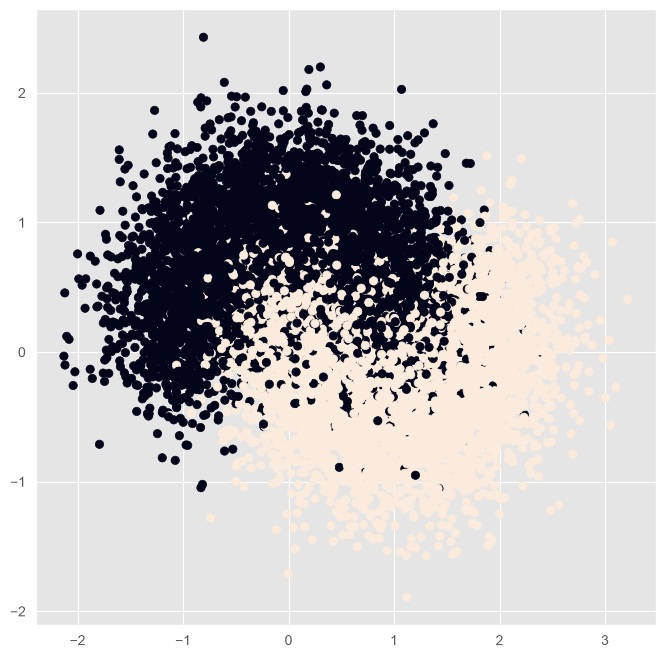

In [4]:
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
plt.style.use('ggplot')

X, y = make_moons(n_samples=10000, noise=0.4, random_state=0)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1], c=y)

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [8, 9, 10],
    'min_samples_split': [5, 10, 20, 50],
    'max_leaf_nodes': [10, 15, 20, 25, 30],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [5, 10, 20]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
)

In [7]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [8, 9, ...], 'max_leaf_nodes': [10, 15, ...], 'min_samples_leaf': [5, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tr

In [8]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 8, 'max_leaf_nodes': 15, 'min_samples_leaf': 5, 'min_samples_split': 5}
0.858625


In [9]:
from sklearn.metrics import accuracy_score

y_pred = grid_search.predict(X_test)
accuracy_score(y_test, y_pred)

0.864

8. Создайте лес.

**а)** Продолжая предыдущее упражнение, сгенерируйте 1 000 поднаборов обучающего набора, каждый из которых содержит 100 случайно выбранных образцов. Подсказка: для этого можете использовать класс `ShuffleSplit` из Scikit-Learn.

**б)** Обучите по одному дереву принятия решений на каждом поднаборе с применением найденных ранее значений гиперпараметров. Оцените полученные 1 000 деревьев принятия решений на испытательном наборе. Поскольку эти деревья принятия решений обучались на наборах меньшего размера, то они, скорее всего, будут выполняться хуже, чем первое дерево принятия решений, давая правильность около 80%.

**в)** Теперь время для магии. Для каждого образца в испытательном наборе сгенерируйте прогнозы посредством 1 000 деревьев принятия решений и сохраните только наиболее частый прогноз (для этого можете воспользоваться функцией `mode()` из SciPy). Это дает вам *мажоритарные прогнозы* (*majority-vote prediction*) на испытательном наборе.

**г)** Оцените эти прогнозы на испытательном наборе: вы должны получить чуть большую правильность, чем у первой модели (выше от примерно 0.5% до 1.5%). Примите поздравления, ведь вы обучили классификатор на основе случайного леса!

In [32]:
from sklearn.model_selection import ShuffleSplit

ss = ShuffleSplit(
    n_splits=1000,
    train_size=300,
    random_state=42
)

trees = []
accuracies = []
for train_index, test_index in ss.split(X_train):
    X_subset = X_train[train_index]
    y_subset = y_train[train_index]

    clf = DecisionTreeClassifier(max_depth=8, max_leaf_nodes=15, min_samples_split=5, min_samples_leaf=5, criterion='entropy')
    clf.fit(X_subset, y_subset)
    trees.append(clf)

    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)



In [19]:
print(f'Средняя точность слабого дерева: {round(sum(accuracies) / len(accuracies) * 100, 1)}%')

Средняя точность слабого дерева: 80.5%


In [33]:
from scipy.stats import mode
import numpy as np

# Собираем предсказания всех деревьев сразу (гораздо быстрее)
predictions = np.array([tree.predict(X_test) for tree in trees])  # shape: (1000, n_samples)

# Мажоритарное голосование
y_pred_random_forest = mode(predictions, axis=0, keepdims=False).mode


In [34]:
print(f'Точность случайного леса на испытательном наборе составляет: {accuracy_score(y_test, y_pred_random_forest)}')

Точность случайного леса на испытательном наборе составляет: 0.8695
